<div align="center">

# Parcial 2 práctico
## Despliegue multi-contenedor, orquestación, arquitectura y análisis del modelo OSI

**Comunicaciones — Ingeniería Mecatrónica**

---

### Integrantes

| Nombre |
|---|
| Samuel Arévalo Gil |
| Juan Pablo Novoa |
| Miguel Gordillo |

**Profesor:** Ing. Andrés Julián Moreno M.Sc.

**Octubre de 2026**

</div>

## Contenido

1. Introducción y objetivos
2. Arquitectura de la solución
3. Implementación
4. Flujos de información
5. Análisis del modelo OSI con evidencia en vivo
6. Análisis de datos de Joomla en PostgreSQL
7. Guía de verificación y demostración
8. Cumplimiento de requisitos
9. Limitaciones y trabajo futuro
10. Conclusiones
11. Referencias

> **Cómo usar este informe.** Este cuaderno se ejecuta dentro del contenedor `jupyter`, conectado a `frontend_net` y a `backend_net`.
> Las celdas de código consultan la red de Docker y la base de datos PostgreSQL **en vivo**.
> Para reproducir todos los resultados use **Run → Run All Cells**.

## 1. Introducción y objetivos

Se diseñó, orquestó y documentó la infraestructura web de una organización académica e industrial que unifica cinco servicios interconectados en un solo clúster de contenedores:

| # | Servicio | Rol |
|---|---|---|
| 1 | **Nginx** | Proxy inverso y único punto de entrada HTTP (puerto 80) |
| 2 | **Joomla** | Portal web institucional (CMS) |
| 3 | **PostgreSQL** | Motor relacional de persistencia del CMS y fuente de datos para Grafana y Jupyter |
| 4 | **Jupyter** | Entorno de análisis con este cuaderno precargado |
| 5 | **Grafana** | Monitoreo con fuente de datos y dashboard aprovisionados automáticamente |

**Objetivo general:** desplegar los cinco servicios con un único comando, sin configuración manual, y analizar su comunicación según el modelo OSI.

**Objetivos específicos:**
- Exponer al host únicamente el puerto 80 y enrutar por prefijo de URL hacia Joomla, Jupyter y Grafana.
- Aislar la base de datos en una red interna sin puertos publicados.
- Instalar Joomla de forma desatendida contra PostgreSQL.
- Aprovisionar Grafana (datasource y dashboard) desde archivos declarativos.
- Analizar las capas 7, 4, 3 y 2 con evidencia obtenida desde los propios contenedores.

**Despliegue (Zero-Touch):**

```bash
git clone https://github.com/smuel2312/parcial2.git parcial2
cd parcial2
cp .env.example .env          # PowerShell: Copy-Item .env.example .env
docker compose up -d
```

## 2. Arquitectura de la solución

### 2.1 Diagrama de red

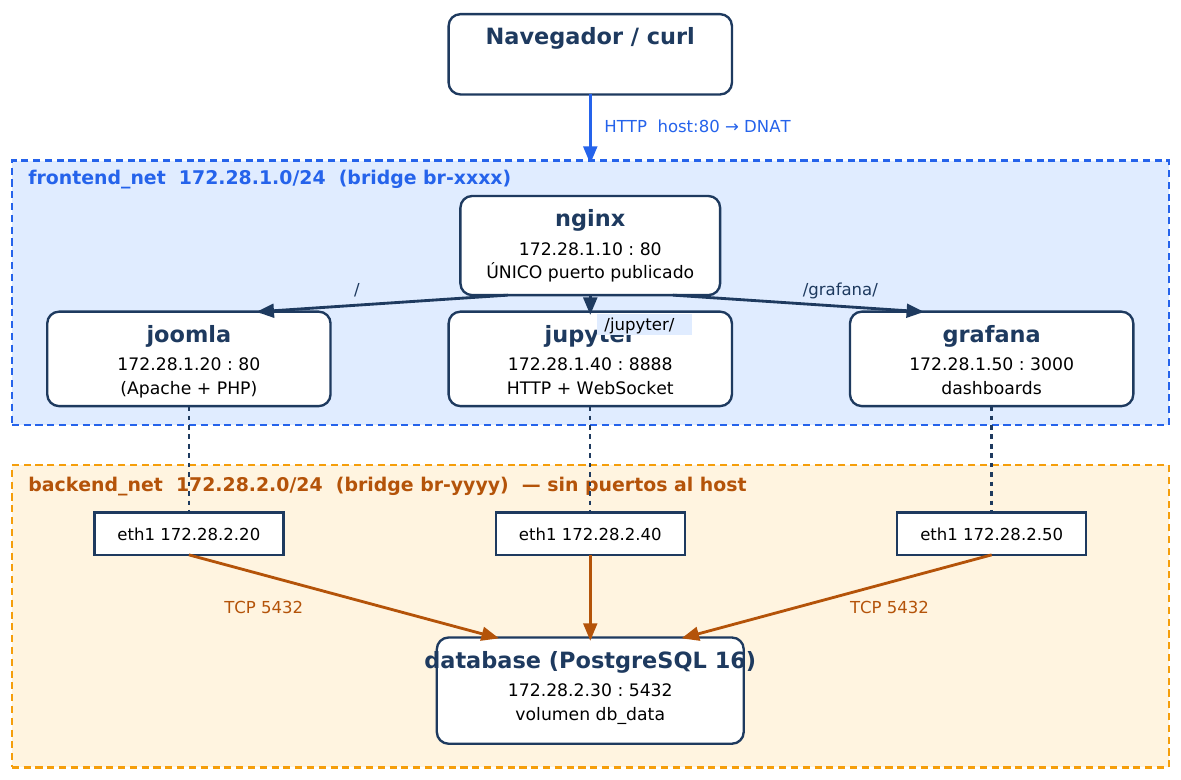

*Figura 1. Topología. En azul y negro, el tráfico HTTP por `frontend_net`. En naranja, las conexiones TCP 5432 hacia PostgreSQL por `backend_net`.*

### 2.2 Tabla de direccionamiento y puertos

| Contenedor | Imagen | frontend_net | backend_net | Puerto interno | Publicado en host |
|---|---|---|---|---|---|
| nginx | `nginx:alpine` | 172.28.1.10 | — | 80/tcp | **80:80** |
| joomla | `joomla:latest` | 172.28.1.20 | 172.28.2.20 | 80/tcp (Apache) | no |
| database | `postgres:16-alpine` | — | 172.28.2.30 | 5432/tcp | **no** |
| jupyter | `jupyter/minimal-notebook` | 172.28.1.40 | 172.28.2.40 | 8888/tcp | no |
| grafana | `grafana/grafana:latest` | 172.28.1.50 | 172.28.2.50 | 3000/tcp | no |

**Resumen de puertos:**
- **Un único puerto expuesto al exterior:** el 80 de nginx.
- **Cinco puertos internos de servicio:** 80 (nginx), 80 (joomla), 8888 (jupyter), 3000 (grafana) y 5432 (PostgreSQL). Nginx y Joomla usan el 80 sin conflicto porque cada contenedor tiene su propio *network namespace* y su propia IP. Un socket se identifica por IP + puerto.
- **Puerto 53:** el DNS embebido de Docker (`127.0.0.11`).
- **Puertos efímeros (32768–60999):** los usa el lado cliente de cada conexión.
- **Interfaces:** nginx 1, joomla 2, jupyter 2, grafana 2, database 1, en total 8 interfaces virtuales (8 pares `veth`).

### 2.3 Redes

| Red | Subred / gateway | Miembros | Propósito |
|---|---|---|---|
| `frontend_net` | 172.28.1.0/24, gw 172.28.1.1 | nginx, joomla, jupyter, grafana | Tráfico HTTP del proxy hacia las aplicaciones |
| `backend_net` | 172.28.2.0/24, gw 172.28.2.1 | database, joomla, jupyter, grafana | Tráfico SQL (TCP 5432) hacia PostgreSQL |

### 2.4 Decisiones de diseño

- **Nginx solo pertenece a `frontend_net`.** El proxy no puede resolver ni alcanzar la base de datos.
- **`database` solo pertenece a `backend_net` y no tiene `ports:`.** Es inaccesible desde el host y desde el proxy.
- **Jupyter y Grafana se conectan también a `backend_net`.** Ambos consultan PostgreSQL, que solo existe en esa red.
- **IPs fijas (`ipv4_address`).** Hacen que este informe y sus evidencias sean reproducibles.

## 3. Implementación

### 3.1 Estructura del repositorio

```
.
├── .env.example                 # variables (PostgreSQL, Joomla, Grafana)
├── docker-compose.yml           # 5 servicios, 2 redes bridge, healthchecks, volúmenes
├── nginx/default.conf           # proxy inverso (/, /jupyter/, /grafana/) + WebSockets
├── jupyter/notebooks/           # cuadernos precargados (este informe y analisis_datos.ipynb)
└── grafana/provisioning/
    ├── datasources/datasource.yml                  # PostgreSQL (database:5432) automático
    └── dashboards/{dashboard.yml, joomla_logs.json} # dashboard de 8 paneles
```

| Archivo | Función |
|---|---|
| `docker-compose.yml` | Define servicios, redes con IPs fijas, volúmenes, healthchecks y orden de arranque |
| `.env.example` | Credenciales por defecto: BD `joomladb`, usuario `joomlauser`, admin de Joomla y de Grafana |
| `nginx/default.conf` | Enrutamiento por prefijo, cabeceras de proxy, WebSocket y keep-alive |
| `datasource.yml` | Crea la conexión de Grafana a PostgreSQL al arrancar |
| `dashboard.yml` | Proveedor que carga los `.json` de la carpeta de dashboards |
| `joomla_logs.json` | Dashboard con 8 paneles |
| `.gitignore` / `.gitattributes` | Excluyen el `.env` real y fuerzan finales de línea LF para evitar errores al clonar en Windows |

### 3.2 Orden de arranque y healthchecks

El arranque se ordena con `depends_on: condition: service_healthy`. Ningún servicio inicia hasta que su dependencia supere el *healthcheck*:

```
database (pg_isready OK)
   ├──► joomla   (instalación automática contra PostgreSQL) ──┐
   ├──► jupyter  (pip install psycopg2, pandas, ...)          ├──► nginx (último)
   └──► grafana  (carga datasource + dashboard)              ──┘
```

| Servicio | Healthcheck | Qué comprueba |
|---|---|---|
| database | `pg_isready -U $POSTGRES_USER -d $POSTGRES_DB` | PostgreSQL acepta conexiones |
| joomla | `curl http://127.0.0.1/` | Apache responde y el sitio está instalado |
| jupyter | `urllib` → `:8888/jupyter/api` | El servidor de Jupyter responde |
| grafana | `wget :3000/api/health` | Grafana está operativo |
| nginx | `wget /nginx-health` | Endpoint propio que devuelve `ok` |

Joomla se instala de forma desatendida gracias a `JOOMLA_DB_TYPE=pgsql` y a las variables `JOOMLA_SITE_NAME` y `JOOMLA_ADMIN_*`.

### 3.3 Persistencia

| Volumen | Montaje | Contenido |
|---|---|---|
| `db_data` | `/var/lib/postgresql/data` | Datos de PostgreSQL |
| `joomla_data` | `/var/www/html` | Archivos del sitio Joomla |
| `grafana_data` | `/var/lib/grafana` | Estado interno de Grafana |
| *bind mounts* | `default.conf`, `provisioning/` (solo lectura), `notebooks/` | Configuración versionada en el repositorio |

`docker compose down` conserva los datos. `docker compose down -v` los elimina, y al volver a levantar el proyecto todo se reinstala sin intervención.

### 3.4 Proxy inverso (Nginx)

```nginx
upstream joomla_upstream  { server joomla:80;    keepalive 16; }
upstream jupyter_upstream { server jupyter:8888; keepalive 16; }
upstream grafana_upstream { server grafana:3000; keepalive 16; }

location /          { proxy_pass http://joomla_upstream;  proxy_set_header Connection ""; }
location /jupyter/  { proxy_pass http://jupyter_upstream;
                      proxy_set_header Upgrade $http_upgrade;
                      proxy_set_header Connection "Upgrade";
                      proxy_read_timeout 86400; proxy_buffering off; }
location /grafana/  { proxy_pass http://grafana_upstream;
                      proxy_set_header Upgrade $http_upgrade;
                      proxy_set_header Connection $connection_upgrade; }
```

- **`upstream` + `keepalive 16`:** mantiene hasta 16 conexiones TCP reutilizables hacia cada backend y evita un *handshake* por petición.
- **`Connection ""` (Joomla):** elimina la cabecera `close` para que la conexión *keep-alive* no se cierre.
- **`Upgrade` / `Connection` (Jupyter):** son cabeceras *hop-by-hop* y un proxy no las reenvía por defecto. Sin ellas los kernels fallan con *Kernel connection error*.
- **`proxy_read_timeout 86400`:** evita que el WebSocket del kernel se cierre a los 60 s por inactividad.
- **`map $http_upgrade $connection_upgrade` (Grafana):** envía `upgrade` solo cuando el cliente pide WebSocket (Grafana Live).
- **Subpaths:** Jupyter usa `--ServerApp.base_url=/jupyter/` y Grafana `GF_SERVER_SERVE_FROM_SUB_PATH=true` junto con `GF_SERVER_ROOT_URL=.../grafana/`.

| Cabecera inyectada | Valor | Propósito |
|---|---|---|
| `Host` | `$host` | URLs y redirecciones con el host real (`localhost`), no con `joomla:80` |
| `X-Real-IP` | `$remote_addr` | IP real del cliente; sin ella el backend vería 172.28.1.10 |
| `X-Forwarded-For` | `$proxy_add_x_forwarded_for` | Cadena de IPs atravesadas |
| `X-Forwarded-Proto` | `$scheme` | Esquema original (http/https); evita bucles de redirección |

### 3.5 Grafana

Grafana se conecta a PostgreSQL mediante la fuente de datos aprovisionada `datasource.yml` (uid `postgres-joomla`). Toma host, usuario y contraseña de las variables de entorno del contenedor y usa un pool de `maxOpenConns: 10`, `maxIdleConns: 5` y `connMaxLifetime: 14400 s`. El acceso es anónimo con rol **Viewer**, el dashboard se fija como página de inicio y se refresca cada 30 s. Con `editable: false` y `allowUiUpdates: false` la configuración queda declarativa.

| # | Panel | Tipo | Fuente | Origen |
|---|---|---|---|---|
| 1 | Conexiones activas a PostgreSQL | stat | `pg_stat_activity` | Real |
| 2 | Tamaño de la base de datos | stat | `pg_database_size()` | Real |
| 3 | Tablas de Joomla instaladas | stat | `information_schema.tables` | Real |
| 4 | Transacciones confirmadas | stat | `pg_stat_database.xact_commit` | Real |
| 5 | Tráfico HTTP hacia Joomla | serie de tiempo | `generate_series` + función seno + `random()` | Simulado |
| 6 | Distribución de códigos HTTP | dona | Valores fijos (`VALUES`) | Simulado |
| 7 | Filas insertadas por tabla | barras | `pg_stat_user_tables` | Real |
| 8 | Logs de acciones de Joomla | tabla | `jos_action_logs` + `jos_users` | Real |

### 3.6 Jupyter

El contenedor monta `./jupyter/notebooks` en `/home/jovyan/work`. Arranca sin token, instala `psycopg2-binary`, `sqlalchemy`, `pandas` y `matplotlib`, y se publica bajo `/jupyter/`. Recibe las credenciales de PostgreSQL por variables de entorno, las mismas que usa este cuaderno.

## 4. Flujos de información

| # | Flujo | Camino | Protocolos |
|---|---|---|---|
| F1 | Visita a Joomla | Cliente → host:80 → nginx → joomla:80 → database:5432 | HTTP/1.1 → HTTP/1.1 keep-alive → PostgreSQL v3 |
| F2 | Notebook | Cliente → nginx `/jupyter/` → jupyter:8888 (REST + WebSocket) → database:5432 | HTTP Upgrade → WebSocket; PostgreSQL v3 |
| F3 | Dashboard | Cliente → nginx `/grafana/` → grafana:3000 → database:5432 | HTTP/JSON; PostgreSQL v3 (pool) |
| F4 | Logs | Acciones en Joomla → `jos_action_logs` → Grafana y Jupyter | SQL |
| F5 | Healthchecks | Docker Engine ejecuta comandos dentro de cada contenedor | loopback |

**Recorrido de una petición a `http://localhost/`:**

| Paso | Evento | Capa |
|---|---|---|
| 1 | El navegador abre una conexión TCP (SYN, SYN-ACK, ACK) al puerto 80 del host | 4 |
| 2 | El kernel aplica **DNAT** (iptables) y redirige a 172.28.1.10:80 | 3 |
| 3 | Nginx asocia el prefijo `/` al upstream de Joomla y resuelve `joomla` con el DNS 127.0.0.11 | 7 / 3 |
| 4 | Nginx obtiene por **ARP** la MAC de 172.28.1.20; la trama cruza su `veth` y el puente `br-*` | 2 |
| 5 | Nginx reenvía la petición (o reutiliza una conexión *keep-alive*) y añade las cabeceras `X-Forwarded-*` | 7 / 4 |
| 6 | Joomla consulta `database:5432` por `eth1` (backend_net) y se autentica con SCRAM-SHA-256 | 7 / 4 / 3 |
| 7 | La respuesta HTML regresa por el mismo camino | — |

## 5. Análisis del modelo OSI con evidencia en vivo

Las celdas de esta sección se ejecutan **desde el contenedor `jupyter`**, que tiene una interfaz en cada red. Así se obtiene evidencia real de cada capa.

In [ ]:
# Configuración común: librerías, conexión a PostgreSQL y utilidades de red
import os, socket, struct, fcntl, json, urllib.request
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
%matplotlib inline
pd.set_option("display.max_colwidth", 80)

DB_USER = os.getenv("POSTGRES_USER", "joomlauser")
DB_PASS = os.getenv("POSTGRES_PASSWORD", "joomlapassword")
DB_HOST = os.getenv("POSTGRES_HOST", "database")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB", "joomladb")
PREFIX  = os.getenv("JOOMLA_DB_PREFIX", "jos_")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_size=5, pool_pre_ping=True,   # pool de conexiones (Capa 4/7)
)

def q(sql, **params):
    """Ejecuta una consulta y devuelve un DataFrame (o None si falla)."""
    try:
        return pd.read_sql(text(sql), engine, params=params)
    except Exception as e:
        print("Error en la consulta:", type(e).__name__, str(e).splitlines()[0])
        return None

def hex_ip(h):
    """Convierte una IP hexadecimal little-endian de /proc/net/* a notación decimal."""
    return ".".join(str(int(h[i:i + 2], 16)) for i in (6, 4, 2, 0))

def ip_de_interfaz(ifname):
    s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    try:
        return socket.inet_ntoa(fcntl.ioctl(s.fileno(), 0x8915, struct.pack("256s", ifname[:15].encode()))[20:24])
    except OSError:
        return "-"

print("Contenedor:", socket.gethostname(), "| BD destino:", f"{DB_HOST}:{DB_PORT}/{DB_NAME}")

### 5.1 Capa 7 — Aplicación

**HTTP con proxy inverso.** Nginx termina la conexión del cliente y abre otra hacia el backend (`proxy_pass`). El enrutamiento por prefijo de URI (`/`, `/jupyter/`, `/grafana/`) es un *virtual hosting* por ruta, decidido completamente en Capa 7.

**WebSocket (RFC 6455).** La ejecución de celdas de Jupyter viaja por `/jupyter/api/kernels/<id>/channels`:

```
GET /jupyter/api/kernels/…/channels HTTP/1.1
Upgrade: websocket
Connection: Upgrade
Sec-WebSocket-Key: dGhlIHNhbXBsZSBub25jZQ==
Sec-WebSocket-Version: 13

HTTP/1.1 101 Switching Protocols
Upgrade: websocket
Connection: Upgrade
Sec-WebSocket-Accept: s3pPLMBiTxaQ9kYGzzhZRbK+xOo=
```

**Protocolo de PostgreSQL (Frontend/Backend v3).** Joomla (PDO pgsql), Grafana (driver Go `pgx`) y Jupyter (`psycopg2`/libpq) siguen la misma secuencia:
1. `StartupMessage` (versión 3.0, usuario y base de datos).
2. `AuthenticationSASL`, intercambio **SCRAM-SHA-256** y `AuthenticationOk`.
3. `ParameterStatus`, `BackendKeyData` y `ReadyForQuery`.
4. Consultas simples (`Query`) o extendidas (`Parse`/`Bind`/`Execute`/`Sync`, usadas por las sentencias preparadas de PDO).
5. Respuestas `RowDescription`, `DataRow`, `CommandComplete`; cierre con `Terminate`.

**Logs de Joomla.** Se registran como filas en `jos_action_logs` (fecha, usuario, extensión, evento e IP). La IP aparece como `COM_ACTIONLOGS_DISABLED` porque el registro de IP viene desactivado por defecto en Joomla.

**Evidencia:** peticiones HTTP a cada servicio por su nombre DNS, y parámetros del protocolo PostgreSQL negociados en la sesión.

In [ ]:
# Capa 7: peticiones HTTP directas a cada servicio a través de frontend_net
destinos = {
    "nginx  /nginx-health":          "http://nginx/nginx-health",
    "joomla /":                      "http://joomla/",
    "grafana /grafana/api/health":   "http://grafana:3000/grafana/api/health",
    "jupyter /jupyter/api":          "http://127.0.0.1:8888/jupyter/api",
}
filas = []
for nombre, url in destinos.items():
    try:
        with urllib.request.urlopen(url, timeout=5) as r:
            filas.append({"destino": nombre, "código HTTP": r.status,
                          "Server": r.headers.get("Server", "-"),
                          "Content-Type": r.headers.get("Content-Type", "-")})
    except Exception as e:
        filas.append({"destino": nombre, "código HTTP": f"error: {type(e).__name__}", "Server": "-", "Content-Type": "-"})
pd.DataFrame(filas)

In [ ]:
# Capa 7: sesión del protocolo PostgreSQL v3
with engine.connect() as conn:
    info = {
        "Versión del servidor": conn.execute(text("SELECT version()")).scalar(),
        "Cifrado de contraseñas": conn.execute(text("SHOW password_encryption")).scalar(),
        "client_encoding (Capa 6)": conn.execute(text("SHOW client_encoding")).scalar(),
        "Usuario / base": f"{conn.execute(text('SELECT current_user')).scalar()} / {conn.execute(text('SELECT current_database()')).scalar()}",
    }
pd.Series(info, name="valor").to_frame()

### 5.2 Capas 6 y 5 — Presentación y Sesión

- **Presentación:** codificación UTF-8 (`client_encoding`), JSON en las APIs de Grafana y Jupyter, compresión gzip opcional. Dentro de la red interna no se usa TLS (`sslmode=disable`), lo cual es aceptable porque `backend_net` no es accesible desde el host.
- **Sesión:** cookies de sesión de Joomla y Grafana, sesiones de kernel de Jupyter y la sesión autenticada de PostgreSQL, que dura mientras la conexión TCP siga abierta.

### 5.3 Capa 4 — Transporte

| Puerto | Servicio | Socket de escucha | Clientes |
|---|---|---|---|
| 80/tcp | nginx | `0.0.0.0:80` (publicado) | Clientes externos |
| 80/tcp | joomla | `172.28.1.20:80` | nginx |
| 8888/tcp | jupyter | `172.28.1.40:8888` | nginx |
| 3000/tcp | grafana | `172.28.1.50:3000` | nginx |
| 5432/tcp | database | `172.28.2.30:5432` | joomla, jupyter, grafana |

- **Multiplexación:** cada conexión se identifica por la 4-tupla (IP origen, puerto efímero, IP destino, puerto destino). `database:5432` atiende simultáneamente a tres clientes, con un proceso *backend* por conexión.
- **Fiabilidad:** todo el tráfico de aplicación es TCP (handshake de 3 vías, ventana deslizante, retransmisiones). Solo el DNS interno usa UDP.
- **Keep-alive HTTP:** `keepalive 16` en los upstream de Nginx reutiliza conexiones hacia los backends.
- **TCP keep-alive:** PostgreSQL usa los valores del kernel (7200 s) para detectar clientes caídos. Los WebSockets usan *ping/pong*.
- **Connection pooling:** Grafana (10 conexiones abiertas, 5 inactivas) y SQLAlchemy (`pool_size=5`) amortizan el costo del handshake TCP y de SCRAM. Joomla (PHP) abre una conexión por petición.

**Evidencia:** conexiones activas vistas desde PostgreSQL, sockets TCP del propio contenedor y pruebas de alcance por puerto.

In [ ]:
# Capa 4: conexiones TCP hacia PostgreSQL vistas por el servidor (un proceso backend por conexión)
df = q("""
    SELECT client_addr::text AS ip_cliente, client_port AS puerto_efimero,
           COALESCE(NULLIF(application_name, ''), '-') AS aplicacion, state AS estado
    FROM pg_stat_activity
    WHERE datname = current_database() AND client_addr IS NOT NULL
    ORDER BY client_addr, client_port
""")
if df is not None:
    nombres = {"172.28.2.20": "joomla", "172.28.2.40": "jupyter", "172.28.2.50": "grafana"}
    df.insert(1, "contenedor", df["ip_cliente"].map(nombres).fillna("?"))
df

In [ ]:
# Capa 4: sockets TCP del contenedor jupyter, leídos de /proc/net/tcp
ESTADOS = {"01": "ESTABLISHED", "06": "TIME_WAIT", "08": "CLOSE_WAIT", "0A": "LISTEN"}
socks = []
with open("/proc/net/tcp") as f:
    next(f)
    for linea in f:
        p = linea.split()
        (lip, lport), (rip, rport) = p[1].split(":"), p[2].split(":")
        socks.append({"local": f"{hex_ip(lip)}:{int(lport, 16)}",
                      "remoto": f"{hex_ip(rip)}:{int(rport, 16)}",
                      "estado": ESTADOS.get(p[3], p[3])})
socks = pd.DataFrame(socks)
socks[socks["estado"].isin(["LISTEN", "ESTABLISHED"])].sort_values("estado").reset_index(drop=True)

In [ ]:
# Capa 4: prueba de alcance TCP (handshake de 3 vías) a cada puerto de servicio
pruebas = [("nginx", 80), ("joomla", 80), ("grafana", 3000), ("database", 5432)]
res = []
for host, puerto in pruebas:
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM); s.settimeout(3)
    try:
        s.connect((host, puerto))
        res.append({"destino": f"{host}:{puerto}", "resultado": "ABIERTO", "puerto local efímero": s.getsockname()[1]})
    except Exception as e:
        res.append({"destino": f"{host}:{puerto}", "resultado": f"falla ({type(e).__name__})", "puerto local efímero": "-"})
    finally:
        s.close()
pd.DataFrame(res)

### 5.4 Capa 3 — Red

- **Direccionamiento:** dos subredes /24 definidas en `ipam`, con IPs fijas. El gateway `.1` es la IP del puente en el host. Los contenedores conectados a ambas redes tienen dos interfaces (`eth0`, `eth1`).
- **Aislamiento:** cada red es un puente Linux distinto, y Docker instala reglas iptables (`DOCKER-ISOLATION-STAGE-1/2` o `DOCKER-FORWARD`) que descartan el reenvío entre puentes. Nginx no tiene ruta hacia 172.28.2.0/24. Los contenedores con dos interfaces no enrutan, porque `ip_forward` está desactivado dentro de ellos.
- **DNS embebido (`127.0.0.11`):** Docker responde con la IP del servicio **en la red compartida con quien pregunta**. `joomla` resuelve `database` → 172.28.2.30, mientras que `nginx` recibe `NXDOMAIN`.
- **NAT:** DNAT de entrada (`host:80 → 172.28.1.10:80`) y MASQUERADE de salida (con él, por ejemplo, Jupyter descarga paquetes con pip). En Docker Desktop esto ocurre dentro de la VM de WSL2.

**Evidencia:** interfaces e IPs del contenedor, tabla de rutas, servidor DNS y resolución de nombres.

In [ ]:
# Capa 3: interfaces, IPs y tabla de rutas del contenedor jupyter
interfaces = [i for i in sorted(os.listdir("/sys/class/net")) if i != "lo"]
display(pd.DataFrame([{"interfaz": i, "IPv4": ip_de_interfaz(i)} for i in interfaces]))

rutas = []
with open("/proc/net/route") as f:
    next(f)
    for linea in f:
        p = linea.split()
        rutas.append({"interfaz": p[0], "destino": hex_ip(p[1]), "gateway": hex_ip(p[2]), "máscara": hex_ip(p[7])})
pd.DataFrame(rutas)

In [ ]:
# Capa 3: DNS embebido de Docker y resolución de nombres de servicio
print(open("/etc/resolv.conf").read())
res = []
for nombre in ["nginx", "joomla", "jupyter", "grafana", "database"]:
    try:
        res.append({"nombre": nombre, "IPs resueltas": ", ".join(sorted(set(socket.gethostbyname_ex(nombre)[2])))})
    except socket.gaierror as e:
        res.append({"nombre": nombre, "IPs resueltas": f"NXDOMAIN ({e})"})
pd.DataFrame(res)

> **Aislamiento.** Esta prueba no puede hacerse desde Jupyter, porque Jupyter pertenece a ambas redes. Se verifica desde el proxy:
> ```bash
> docker compose exec nginx nslookup database 127.0.0.11      # NXDOMAIN
> docker compose exec nginx sh -c "nc -zv -w 3 172.28.2.30 5432 || echo BLOQUEADO"
> docker compose exec joomla bash -c "echo > /dev/tcp/database/5432 && echo ALCANZABLE"
> ```

### 5.5 Capa 2 — Enlace de datos

- **Puentes `br-*`:** cada red de usuario crea un Linux bridge que se comporta como un **switch virtual**, con tabla de aprendizaje de MAC (FDB).
- **Pares `veth`:** cada interfaz de contenedor es un cable virtual con un extremo dentro del contenedor (`eth0`/`eth1`) y otro (`vethXXXX`) conectado al puente en el host.
- **ARP:** antes del primer segmento TCP hacia 172.28.2.30, el contenedor emite `ARP who-has 172.28.2.30 tell 172.28.2.40`. El puente inunda la solicitud, `database` responde con su MAC y ambos la guardan en caché.
- **Tramas:** Ethernet II con MTU 1500.

**Evidencia:** direcciones MAC y MTU de las interfaces, y caché ARP del contenedor después del tráfico generado en las celdas anteriores.

In [ ]:
# Capa 2: MAC y MTU de cada interfaz, y caché ARP (vecinos aprendidos)
macs = [{"interfaz": i,
         "MAC": open(f"/sys/class/net/{i}/address").read().strip(),
         "MTU": open(f"/sys/class/net/{i}/mtu").read().strip()} for i in interfaces]
display(pd.DataFrame(macs))

ip_a_servicio = {"172.28.1.10": "nginx", "172.28.1.20": "joomla", "172.28.1.50": "grafana",
                 "172.28.2.20": "joomla", "172.28.2.30": "database", "172.28.2.50": "grafana",
                 "172.28.1.1": "gateway frontend", "172.28.2.1": "gateway backend"}
arp = []
with open("/proc/net/arp") as f:
    next(f)
    for linea in f:
        p = linea.split()
        arp.append({"IP": p[0], "servicio": ip_a_servicio.get(p[0], "-"), "MAC": p[3], "interfaz": p[5]})
pd.DataFrame(arp)

### 5.6 Capa 1 — Física

No existe un medio físico entre contenedores: las tramas se copian en memoria del kernel entre *namespaces*. Solo el tráfico que sale del host (descarga de imágenes o de paquetes pip) atraviesa la tarjeta de red real.

### 5.7 Resumen por capas

| Capa OSI | Elementos del proyecto |
|---|---|
| 7 Aplicación | HTTP/1.1, cabeceras `Host`/`X-Forwarded-*`, WebSocket, protocolo PostgreSQL v3 + SCRAM, APIs REST |
| 6 Presentación | UTF-8, JSON, gzip |
| 5 Sesión | Cookies de Joomla y Grafana, sesiones de kernel, sesión de PostgreSQL |
| 4 Transporte | TCP 80/8888/3000/5432, puertos efímeros, keep-alive, pools de conexión |
| 3 Red | 172.28.1.0/24 y 172.28.2.0/24, DNS 127.0.0.11, DNAT/MASQUERADE, aislamiento con iptables |
| 2 Enlace | `br-*`, `veth*`, MAC, ARP, FDB |
| 1 Física | Memoria del kernel / NIC del host |

## 6. Análisis de datos de Joomla en PostgreSQL

Esta sección cumple el requisito del cuaderno precargado: consulta las tablas de Joomla y genera gráficos con pandas y matplotlib.

In [ ]:
# 6.1 Inventario de tablas: filas vivas y tamaño en disco
tablas = q("""
    SELECT relname AS tabla, n_live_tup AS filas,
           pg_total_relation_size(relid) AS bytes,
           n_tup_ins AS insertadas, n_tup_upd AS actualizadas
    FROM pg_stat_user_tables
    ORDER BY pg_total_relation_size(relid) DESC
""")
if tablas is not None:
    tablas["kB"] = (tablas["bytes"] / 1024).round(1)
    joomla = tablas[tablas["tabla"].str.startswith(PREFIX)]
    print(f"Tablas totales: {len(tablas)}  |  Tablas de Joomla ({PREFIX}*): {len(joomla)}")
    display(tablas.head(15))

In [ ]:
# 6.2 Gráfico: las 15 tablas más grandes
if tablas is None or tablas.empty:
    print("Aún no hay tablas (¿Joomla sigue instalándose?). Vuelva a ejecutar en unos segundos.")
else:
    top = tablas.head(15).sort_values("kB")
    ax = top.plot.barh(x="tabla", y="kB", figsize=(10, 6), color="#3b82f6", legend=False)
    ax.set_title("Top 15 tablas por tamaño en disco (kB)")
    ax.set_xlabel("kB"); ax.set_ylabel("")
    plt.tight_layout(); plt.show()

La tabla más grande es `jos_extensions`, porque guarda el registro de todas las extensiones (componentes, módulos, plugins y plantillas) que Joomla instala por defecto.

In [ ]:
# 6.3 Usuarios y logs de acciones de Joomla
usuarios = q(f'SELECT id, name, username, email, "registerDate" FROM {PREFIX}users')
if usuarios is not None:
    display(usuarios)
logs = q(f"""
    SELECT l.log_date AS fecha, COALESCE(u.username, 'sistema') AS usuario,
           l.extension, l.message_language_key AS evento, l.ip_address AS ip
    FROM {PREFIX}action_logs l LEFT JOIN {PREFIX}users u ON u.id = l.user_id
    ORDER BY l.log_date DESC LIMIT 20
""")
if logs is not None:
    print(f"Últimos registros de {PREFIX}action_logs: {len(logs)}")
    display(logs)

In [ ]:
# 6.4 Gráfico: actividad de escritura (insertadas vs. actualizadas) por tabla de Joomla
if tablas is None:
    print("Sin datos.")
else:
    act = (joomla.assign(total=joomla["insertadas"] + joomla["actualizadas"])
                 .query("total > 0").sort_values("total", ascending=False).head(10))
    if act.empty:
        print("Sin actividad de escritura registrada todavía.")
    else:
        ax = act.plot.bar(x="tabla", y=["insertadas", "actualizadas"], figsize=(11, 5),
                          color=["#10b981", "#f59e0b"], rot=45)
        ax.set_title("Actividad de escritura por tabla de Joomla"); ax.set_ylabel("Filas")
        plt.tight_layout(); plt.show()

In [ ]:
# 6.5 Estadísticas globales de la base de datos
q("""
    SELECT datname AS base, numbackends AS conexiones, xact_commit AS commits,
           xact_rollback AS rollbacks, blks_read AS bloques_leidos_disco, blks_hit AS bloques_en_cache,
           round(100.0 * blks_hit / NULLIF(blks_hit + blks_read, 0), 2) AS cache_hit_pct,
           pg_size_pretty(pg_database_size(datname)) AS tamano
    FROM pg_stat_database WHERE datname = current_database()
""")

## 7. Guía de verificación y demostración

Comandos para ejecutar **en la terminal del host** (bash o PowerShell), desde la raíz del repositorio.

**1. Despliegue y estado**
```bash
docker compose up -d
docker compose ps                     # los 5 servicios en "running (healthy)"
```

**2. Accesos (todo por el puerto 80)**

| URL | Resultado esperado |
|---|---|
| http://localhost/ | Sitio Joomla "Parcial2 Joomla" instalado |
| http://localhost/administrator | Login `admin` / contraseña de `JOOMLA_ADMIN_PASSWORD` |
| http://localhost/jupyter/ | JupyterLab sin token con los cuadernos precargados |
| http://localhost/grafana/ | Dashboard "Joomla - Actividad y Logs" sin login |

**3. Capa 7**
```bash
curl -sI http://localhost/grafana/api/health
curl -si -N http://localhost/jupyter/api/events/subscribe \
  -H "Connection: Upgrade" -H "Upgrade: websocket" \
  -H "Sec-WebSocket-Version: 13" -H "Sec-WebSocket-Key: SGVsbG9QYXJjaWFsMg==" --max-time 3
# Esperado: HTTP/1.1 101 Switching Protocols
docker compose exec database pg_isready -U joomlauser -d joomladb
```

**4. Capa 4**
```bash
docker compose port nginx 80          # 0.0.0.0:80
docker compose port database 5432     # vacío: no publicado
docker compose exec database psql -U joomlauser -d joomladb \
  -c "SELECT client_addr, client_port, state FROM pg_stat_activity WHERE datname='joomladb';"
```

**5. Capa 3**
```bash
docker network inspect parcial2_frontend_net
docker network inspect parcial2_backend_net
docker compose exec nginx cat /etc/resolv.conf            # nameserver 127.0.0.11
docker compose exec nginx nslookup database 127.0.0.11    # NXDOMAIN
docker compose exec nginx sh -c "nc -zv -w 3 172.28.2.30 5432 || echo BLOQUEADO"
```

**6. Capa 2**
```bash
docker compose exec joomla cat /proc/net/arp
# En Linux nativo: ip link show type bridge ; ip link show type veth ; bridge link
```

**7. Dependencia de la base de datos y persistencia**
```bash
docker compose stop database          # Joomla muestra error de conexión y Grafana queda sin datos
docker compose start database
docker compose down && docker compose up -d       # los datos se conservan
docker compose down -v && docker compose up -d    # reinstalación limpia y automática
```

**8. Logs**
```bash
docker compose logs -f nginx          # access log: IP, ruta, código HTTP
docker compose logs joomla
docker compose logs grafana | grep -i provision
```

## 8. Cumplimiento de requisitos

| Requisito | Implementación | Estado |
|---|---|---|
| Despliegue con un único comando | `docker compose up -d` con `.env` por defecto; healthchecks y `depends_on` | ✔ |
| Nginx único puerto publicado (80:80) | Solo `nginx` tiene `ports:` | ✔ |
| Enrutamiento por prefijo `/`, `/jupyter`, `/grafana` | `location` en `default.conf` | ✔ |
| WebSocket para Jupyter | Cabeceras `Upgrade`/`Connection` + `proxy_http_version 1.1` | ✔ |
| Registro de peticiones en Nginx | Access log en la salida estándar (`docker compose logs nginx`) | ✔ |
| Joomla con PostgreSQL (`pgsql`) | Instalación desatendida con `JOOMLA_DB_TYPE=pgsql` | ✔ |
| Logs de Joomla consumibles por Grafana | Logs de actividad en `jos_action_logs`, consultados por Grafana vía PostgreSQL | ✔ (vía PostgreSQL) |
| PostgreSQL solo en `backend_net`, puerto 5432 | Sin `ports:`; única red `backend_net` | ✔ |
| Persistencia en `/var/lib/postgresql/data` | Volumen `db_data` | ✔ |
| Jupyter con cuaderno precargado y ejecutable | Bind mount `./jupyter/notebooks`; consultas y gráficos | ✔ |
| Grafana aprovisionado automáticamente | `provisioning/datasources` y `provisioning/dashboards` | ✔ |
| Al menos dos gráficas funcionales | 8 paneles; 6 con datos reales | ✔ |
| Documentación en Markdown | `README.md`, `INFORME.md` y este cuaderno | ✔ |

## 9. Limitaciones y trabajo futuro

1. **Paneles 5 y 6 de Grafana simulados.** El tráfico HTTP y la distribución de códigos se generan con `generate_series` y valores fijos para ilustrar el flujo. Las métricas reales provienen de PostgreSQL y de `jos_action_logs`. *Mejora:* enviar el access log de Nginx a Grafana con **Loki + Promtail**, o con un volumen de logs compartido, para graficar códigos HTTP e IPs reales.
2. **Salida a Internet desde `backend_net`.** La base de datos es inalcanzable desde el exterior, pero una red bridge común permite tráfico saliente (MASQUERADE). *Mejora:* declarar `internal: true` en `backend_net`. Joomla, Jupyter y Grafana seguirían saliendo por `frontend_net`.
3. **Logs de Apache de Joomla.** La imagen oficial envía `/var/log/apache2` a la salida estándar del contenedor. Se optó por la alternativa permitida: métricas y logs de actividad desde PostgreSQL.
4. **Registro de IP en Joomla.** Viene desactivado por defecto (`COM_ACTIONLOGS_DISABLED`). Puede activarse en *Usuarios → Registro de acciones → Opciones*. Con la cabecera `X-Real-IP`, el sistema registraría la IP real del cliente.
5. **Sin TLS.** El sistema se publica en HTTP. *Mejora:* terminar TLS en Nginx (puerto 443) con un certificado autofirmado o Let's Encrypt.

## 10. Conclusiones

- Docker Compose permitió describir la infraestructura completa (servicios, redes, volúmenes y orden de arranque) en un solo archivo declarativo. El despliegue es reproducible y desatendido.
- Con un proxy inverso como único punto de entrada, la superficie expuesta se reduce a un puerto y el enrutamiento se resuelve en Capa 7, por prefijo de URL. Para WebSocket fue necesario reenviar explícitamente las cabeceras *hop-by-hop*.
- La segmentación en dos redes bridge aisló la base de datos. El DNS embebido de Docker resuelve nombres solo dentro de las redes compartidas, y las reglas de iptables impiden el reenvío entre puentes, como se evidenció en la Sección 5.
- Los *healthchecks* combinados con `depends_on: service_healthy` fueron decisivos para la instalación automática de Joomla, porque evitan condiciones de carrera con PostgreSQL.
- El análisis por capas mostró que una petición atraviesa NAT, resolución DNS, ARP, puentes virtuales, conexiones TCP reutilizadas y protocolos de aplicación distintos (HTTP, WebSocket y PostgreSQL v3), aunque todo ocurra dentro de un mismo host.
- El aprovisionamiento de Grafana y el cuaderno precargado demuestran el principio de configuración como código: la observabilidad queda lista al desplegar, sin pasos manuales.

## 11. Referencias

1. Docker Inc. *Networking overview* y *Bridge network driver*. https://docs.docker.com/engine/network/
2. Docker Inc. *Compose file reference: services, networks, depends_on, healthcheck*. https://docs.docker.com/reference/compose-file/
3. NGINX. *ngx_http_proxy_module* y *WebSocket proxying*. https://nginx.org/en/docs/http/websocket.html
4. I. Fette, A. Melnikov. *RFC 6455: The WebSocket Protocol*. IETF, 2011. https://www.rfc-editor.org/rfc/rfc6455
5. PostgreSQL Global Development Group. *Frontend/Backend Protocol*. https://www.postgresql.org/docs/16/protocol.html
6. PostgreSQL Global Development Group. *The Cumulative Statistics System*. https://www.postgresql.org/docs/16/monitoring-stats.html
7. Grafana Labs. *Provision Grafana*. https://grafana.com/docs/grafana/latest/administration/provisioning/
8. Docker Hub. *joomla* (imagen oficial). https://hub.docker.com/_/joomla
9. Project Jupyter. *Jupyter Docker Stacks*. https://jupyter-docker-stacks.readthedocs.io/